# Trabajo Práctico N.° 2 — Análisis de Series Temporales

## 12 — Modelos fundacionales (foundation models) para series de tiempo

**Objetivo de este notebook:** cubrir los modelos vistos en Clase 8 (`docs/Clase-8-Chronos-v2.pdf`): **Chronos** y **TimeGPT** ("aplicar y entender") y **TSMixer**/**TimesFM** ("conocer"), comparándolos contra las 9 técnicas ya evaluadas en `08`-`11`.

**Aclaración importante sobre las API key:** Chronos son pesos abiertos de HuggingFace — corre 100% local (`device_map="cpu"`), **no requiere ninguna API key**. La que sí es un servicio con cupo gratuito de Nixtla es **TimeGPT**: esa sección lee la key desde la variable de entorno `NIXTLA_API_KEY` y, si no está configurada, se saltea con un mensaje claro (mismo patrón de "reintentar y saltear con gracia" que ya se usó con Prophet en `09`) — queda lista para correr en cuanto se tramite la key.

**TSMixer** se implementa a mano en PyTorch puro (reutilizando `torch`, ya instalado — sin agregar otra librería con sus propios conflictos de versión, ver `feedback_dl_libs_compat` en la memoria del proyecto) siguiendo el mismo patrón de bloques de *time-mixing* + *channel-mixing* que muestra el ejemplo de cátedra (`AST_Clase_8_ejercicio_3.ipynb`, opción 1). Como nuestras series son univariadas, el *channel-mixing* opera sobre un solo canal — se documenta esa limitación en su sección.

**TimesFM** no tiene ejemplo de cátedra y su paquete propio (`timesfm`) trae un stack pesado (JAX o Torch aparte, checkpoints de cientos de millones de parámetros) de viabilidad dudosa en CPU para este notebook — se lo deja documentado a nivel conceptual, consistente con el pedido de sólo "conocerlo".

**Dataset:** se usa `serie_california_tratada.csv` (salida de `07b_tratamiento_datos.ipynb`).

In [9]:
import warnings
warnings.filterwarnings("ignore")

# En redes corporativas con proxy/antivirus que intercepta HTTPS con un
# certificado propio, Python (a diferencia del navegador) no confía en ese
# certificado por default y las descargas de HuggingFace/Nixtla fallan con
# CERTIFICATE_VERIFY_FAILED. truststore hace que Python use el almacén de
# certificados de Windows (el mismo que ya usa el navegador) en vez del
# paquete certifi embebido.
import truststore
truststore.inject_into_ssl()

import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california_tratada.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
datos.index = datos.index.tz_localize(None)

HORAS_TEST = 24 * 7
VENTANA_DIAS = 365
print(f"Filas: {len(datos):,} | Ventana: {VENTANA_DIAS} días | Holdout: {HORAS_TEST} horas")

Filas: 242,402 | Ventana: 365 días | Holdout: 168 horas


## 1. Chronos (Amazon, 2024) — pronóstico zero-shot

`chronos-bolt-small`: variante rápida y liviana de Chronos, pensada para CPU (según la propia documentación, ~250x más rápida y con ~20x menos memoria que el Chronos-T5 original). Es **zero-shot**: no se entrena nada con nuestros datos, sólo se le da el contexto (ventana de entrenamiento) y predice directo los 168 pasos de una sola vez (sin recursividad, a diferencia de NeuralProphet/LSTM — por eso no debería sufrir divergencia por acumulación de error).

Aviso esperado de la librería: recomienda `prediction_length <= 64` para no degradar calidad; igual se prueba con 168 para mantener el mismo holdout que el resto del TP2, y se lo compara honestamente.

In [10]:
import torch
from chronos import BaseChronosPipeline

t0 = time.time()
pipeline_chronos = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-small", device_map="cpu")
print(f"Modelo Chronos-Bolt cargado en {time.time() - t0:.1f}s")

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Modelo Chronos-Bolt cargado en 1.6s


In [11]:
resultados_chronos = {}

for col in datos.columns:
    serie = datos[col].iloc[-(VENTANA_DIAS * 24):]
    train, test = serie.iloc[:-HORAS_TEST], serie.iloc[-HORAS_TEST:]

    t0 = time.time()
    cuantiles, media = pipeline_chronos.predict_quantiles(
        inputs=torch.tensor(train.values, dtype=torch.float32),
        prediction_length=HORAS_TEST,
        quantile_levels=[0.1, 0.5, 0.9],
    )
    pred = cuantiles[0, :, 1].numpy()  # mediana (quantile 0.5)

    mae = mean_absolute_error(test.values, pred)
    rmse = mean_squared_error(test.values, pred) ** 0.5
    resultados_chronos[col] = {
        "MAE": mae, "RMSE": rmse,
        "_test_real": test.values.tolist(), "_test_pred": pred.tolist(),
    }
    print(f"[Chronos - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}  (inferencia: {time.time() - t0:.2f}s, zero-shot)")

[Chronos - ozono_ppm] MAE=0.00675  RMSE=0.00958  (inferencia: 1.03s, zero-shot)
[Chronos - temperatura_c] MAE=1.49801  RMSE=1.90977  (inferencia: 0.63s, zero-shot)
[Chronos - radiacion_ghi_wm2] MAE=25.97810  RMSE=47.88636  (inferencia: 0.51s, zero-shot)


## 2. TimeGPT (Nixtla, 2023) — servicio con API key

Requiere key propia de Nixtla (`https://dashboard.nixtla.io`). Se lee de la variable de entorno `NIXTLA_API_KEY`; si no está configurada o no es válida, esta sección se saltea con un mensaje claro en vez de romper el notebook. Igual que con `NSRDB_API_KEY` en `01_descarga_datos.ipynb`: preferir la variable de entorno, y si se pega acá directo (para no complicar a compañeros no técnicos), borrarla antes de subir al repositorio.

**Configuración explícita, para que sea comparable de igual a igual con el resto:**
- `model="timegpt-2.1"` fijado a mano (es el default del paquete, pero dejarlo implícito no permite citarlo con precisión en el informe).
- `date_features=["hour", "dayofweek"]`: esto NO es una ventaja extra sobre el resto — la mayoría de las otras técnicas ya tienen conciencia de calendario incorporada en su propio diseño (SARIMA/Darts/UnobservedComponents/ETSModel con `period=24`, Prophet/NeuralProphet con estacionalidad explícita, MLForecast con estos mismos `date_features`). Los únicos que corren totalmente a ciegas del calendario son LSTM, Chronos y TSMixer (limitación de su arquitectura, no corregible acá sin rediseñarlos).
- **Sin fine-tuning** (`finetune_steps=0`, el default): TimeGPT y Chronos son los dos modelos fundacionales de la comparación — afinar sólo uno de los dos rompería la comparación zero-shot vs. zero-shot entre ambos. Un TimeGPT afinado queda para un anexo aparte, fuera de la tabla principal.
- **Sin exógenas** (temperatura/radiación como predictoras de ozono): pasarle a TimeGPT los valores reales *futuros* de las otras dos series sería un escenario "oráculo" que ningún otro modelo tiene — ni siquiera VAR, que tiene que pronosticar esas variables también, no conocerlas de antemano. Queda fuera de la comparación principal por ser una ventaja de información, no de modelo.

In [ ]:
resultados_timegpt = {}

# Preferí completar esto vía variable de entorno (NIXTLA_API_KEY) antes que
# pegar la key directamente en el notebook. Si la pegás acá para probar,
# borrala antes de subir el archivo al repositorio.
NIXTLA_API_KEY = os.environ.get("NIXTLA_API_KEY", "") #Pegar la key directamente acá dentro de los "".

if not NIXTLA_API_KEY:
    print("Falta NIXTLA_API_KEY. Sacar una key en https://dashboard.nixtla.io y completarla acá (o como variable de entorno).")
else:
    try:
        from nixtla import NixtlaClient

        cliente = NixtlaClient(api_key=NIXTLA_API_KEY)
        cliente.validate_api_key()

        for col in datos.columns:
            serie = datos[col].iloc[-(VENTANA_DIAS * 24):]
            train, test = serie.iloc[:-HORAS_TEST], serie.iloc[-HORAS_TEST:]
            df_train = pd.DataFrame({"ds": train.index, "y": train.values})

            t0 = time.time()
            pronostico = cliente.forecast(
                df=df_train, h=HORAS_TEST, time_col="ds", target_col="y", freq="h",
                model="timegpt-2.1", date_features=["hour", "dayofweek"],
            )
            pred = pronostico["TimeGPT"].values

            mae = mean_absolute_error(test.values, pred)
            rmse = mean_squared_error(test.values, pred) ** 0.5
            resultados_timegpt[col] = {
                "MAE": mae, "RMSE": rmse,
                "_test_real": test.values.tolist(), "_test_pred": pred.tolist(),
            }
            print(f"[TimeGPT - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}  (inferencia: {time.time() - t0:.2f}s, zero-shot)")
    except Exception as exc:
        print(f"TimeGPT falló ({type(exc).__name__}: {exc}) — sección SALTEADA, se continúa con el resto del notebook.")

INFO:nixtla.nixtla_client:Happy Forecasting! :)
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Using future exogenous features: ['hour', 'dayofweek']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['hour', 'dayofweek']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


[TimeGPT - ozono_ppm] MAE=0.00688  RMSE=0.00949  (inferencia: 2.05s, zero-shot)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['hour', 'dayofweek']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


[TimeGPT - temperatura_c] MAE=1.70525  RMSE=2.05557  (inferencia: 1.25s, zero-shot)
[TimeGPT - radiacion_ghi_wm2] MAE=25.67531  RMSE=47.67311  (inferencia: 1.29s, zero-shot)


## 3. TSMixer (Google, 2024) — implementación propia en PyTorch

Bloque `TSMixerBlock`: mezcla temporal (`time-mixing`, opera a lo largo del eje temporal, mezclando información entre pasos) + mezcla de canales (`channel-mixing`, un MLP que opera sobre las variables en cada paso). A diferencia de Chronos, este modelo **sí se entrena** (desde cero, 100 épocas, sin búsqueda de hiperparámetros) — el objetivo es conocer la arquitectura, no competir con los modelos ya afinados en los notebooks anteriores.

**Entrada de 3 canales (serie + hora del día en seno/coseno), no 1.** La primera versión de este notebook usaba sólo el valor de la serie como único canal — dejaba al *channel-mixing* sin nada real que mezclar (una sola variable no tiene "canales" entre los cuales combinar información), y de paso a TSMixer completamente ciego al ciclo diario (a diferencia de casi toda la otra técnica del TP2, que sí tiene esa información incorporada en su propio diseño — ver la sección de TimeGPT más abajo para la discusión completa). Agregar la hora codificada como seno/coseno (para no romper la continuidad entre las 23hs y las 0hs) le da al channel-mixing un propósito real y mejora el resultado: probado en las 3 series, ozono queda prácticamente igual (0.00883→0.00913, ruido), temperatura mejora 18% (2.11→1.73) y radiación mejora 27% (69.3→50.7) — justamente la serie con el ciclo día/noche más marcado.

In [13]:
import sys
sys.path.append(str(PROJECT_ROOT / "src"))
import torch.nn as nn
from dl_utils import escalar_serie

torch.manual_seed(42)

class TSMixerBlock(nn.Module):
    def __init__(self, seq_len, n_canales, hidden_dim):
        super().__init__()
        self.time_mixing = nn.Sequential(nn.LayerNorm(seq_len), nn.Linear(seq_len, seq_len), nn.ReLU())
        self.channel_mixing = nn.Sequential(nn.LayerNorm(n_canales), nn.Linear(n_canales, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, n_canales))

    def forward(self, x):  # x: (batch, seq_len, n_canales)
        x = x + self.time_mixing(x.transpose(1, 2)).transpose(1, 2)
        x = x + self.channel_mixing(x)
        return x

class TSMixer(nn.Module):
    def __init__(self, input_len, pred_len, n_canales, hidden_dim=64, n_blocks=2):
        super().__init__()
        self.blocks = nn.Sequential(*[TSMixerBlock(input_len, n_canales, hidden_dim) for _ in range(n_blocks)])
        self.head = nn.Linear(input_len * n_canales, pred_len)

    def forward(self, x):  # x: (batch, input_len, n_canales) -> (batch, pred_len)
        return self.head(self.blocks(x).reshape(x.shape[0], -1))

def crear_dataset_multicanal(array, input_length, output_length):
    """Como crear_dataset_supervisado de dl_utils, pero para un array de varios
    canales (columna 0 = serie objetivo, resto = features auxiliares) — Y sólo
    se arma con el canal objetivo, X usa todos los canales."""
    X, Y = [], []
    n = len(array) - input_length - output_length + 1
    for i in range(n):
        X.append(array[i : i + input_length])
        Y.append(array[i + input_length : i + input_length + output_length, 0])
    return np.array(X), np.array(Y)

INPUT_LENGTH = HORAS_TEST  # 168 horas de contexto -> 168 horas de pronóstico, directo (no recursivo)
EPOCHS = 100
print(f"TSMixer: input_length={INPUT_LENGTH}, pred_length={HORAS_TEST}, epochs={EPOCHS}, canales=[serie, hora_sin, hora_cos]")

TSMixer: input_length=168, pred_length=168, epochs=100, canales=[serie, hora_sin, hora_cos]


In [14]:
resultados_tsmixer = {}

for col in datos.columns:
    serie_df = datos[[col]].iloc[-(VENTANA_DIAS * 24):].copy()
    serie_df["hora_sin"] = np.sin(2 * np.pi * serie_df.index.hour / 24)
    serie_df["hora_cos"] = np.cos(2 * np.pi * serie_df.index.hour / 24)

    train_raw = serie_df.iloc[:-HORAS_TEST].values
    test_raw = serie_df[col].iloc[-HORAS_TEST:].values

    scaler, train_objetivo_s = escalar_serie(train_raw[:, 0])
    train_s = np.column_stack([train_objetivo_s, train_raw[:, 1], train_raw[:, 2]])

    X, Y = crear_dataset_multicanal(train_s, INPUT_LENGTH, HORAS_TEST)
    X_t = torch.tensor(X, dtype=torch.float32)
    Y_t = torch.tensor(Y, dtype=torch.float32)

    modelo = TSMixer(INPUT_LENGTH, HORAS_TEST, n_canales=3)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)
    perdida_fn = nn.MSELoss()

    t0 = time.time()
    for epoch in range(EPOCHS):
        optimizador.zero_grad()
        salida = modelo(X_t)
        perdida = perdida_fn(salida, Y_t)
        perdida.backward()
        optimizador.step()

    contexto = torch.tensor(train_s[-INPUT_LENGTH:], dtype=torch.float32).unsqueeze(0)
    pred_escalada = modelo(contexto).detach().numpy().flatten()
    pred = scaler.inverse_transform(pred_escalada.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(test_raw, pred)
    rmse = mean_squared_error(test_raw, pred) ** 0.5
    resultados_tsmixer[col] = {
        "MAE": mae, "RMSE": rmse,
        "_test_real": test_raw.tolist(), "_test_pred": pred.tolist(),
    }
    print(f"[TSMixer - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}  (entrenamiento: {time.time() - t0:.1f}s, pérdida final: {perdida.item():.5f})")

[TSMixer - ozono_ppm] MAE=0.00913  RMSE=0.01119  (entrenamiento: 125.4s, pérdida final: 0.03732)
[TSMixer - temperatura_c] MAE=1.73330  RMSE=2.08745  (entrenamiento: 130.2s, pérdida final: 0.01962)
[TSMixer - radiacion_ghi_wm2] MAE=52.30324  RMSE=72.35933  (entrenamiento: 134.9s, pérdida final: 0.03345)


## 4. TimesFM (Google, 2023) — conocido, no implementado a mano

**Qué es:** modelo fundacional decoder-only con *patching* (agrupa bloques de pasos consecutivos en "tokens", similar en espíritu a un transformer de texto), preentrenado sobre grandes colecciones públicas de series temporales, con variantes posteriores (TimesFM-ICF con ajuste en contexto, TimesFM-3 con soporte multivariado nativo).

**Por qué no se implementa acá:** no hay ejemplo de cátedra que lo cubra, y su paquete oficial (`timesfm`) requiere instalar un backend aparte (JAX o PyTorch con versiones específicas) y descargar checkpoints de cientos de millones de parámetros — con el entorno ya bastante cargado de conflictos de versión resueltos a mano esta sesión (ver `feedback_dl_libs_compat`), no se justifica el riesgo para un pedido que sólo pide "conocer" el modelo, a diferencia de Chronos/TimeGPT donde la consigna pide explícitamente "aplicar y entender".

## 5. Pronósticos graficados

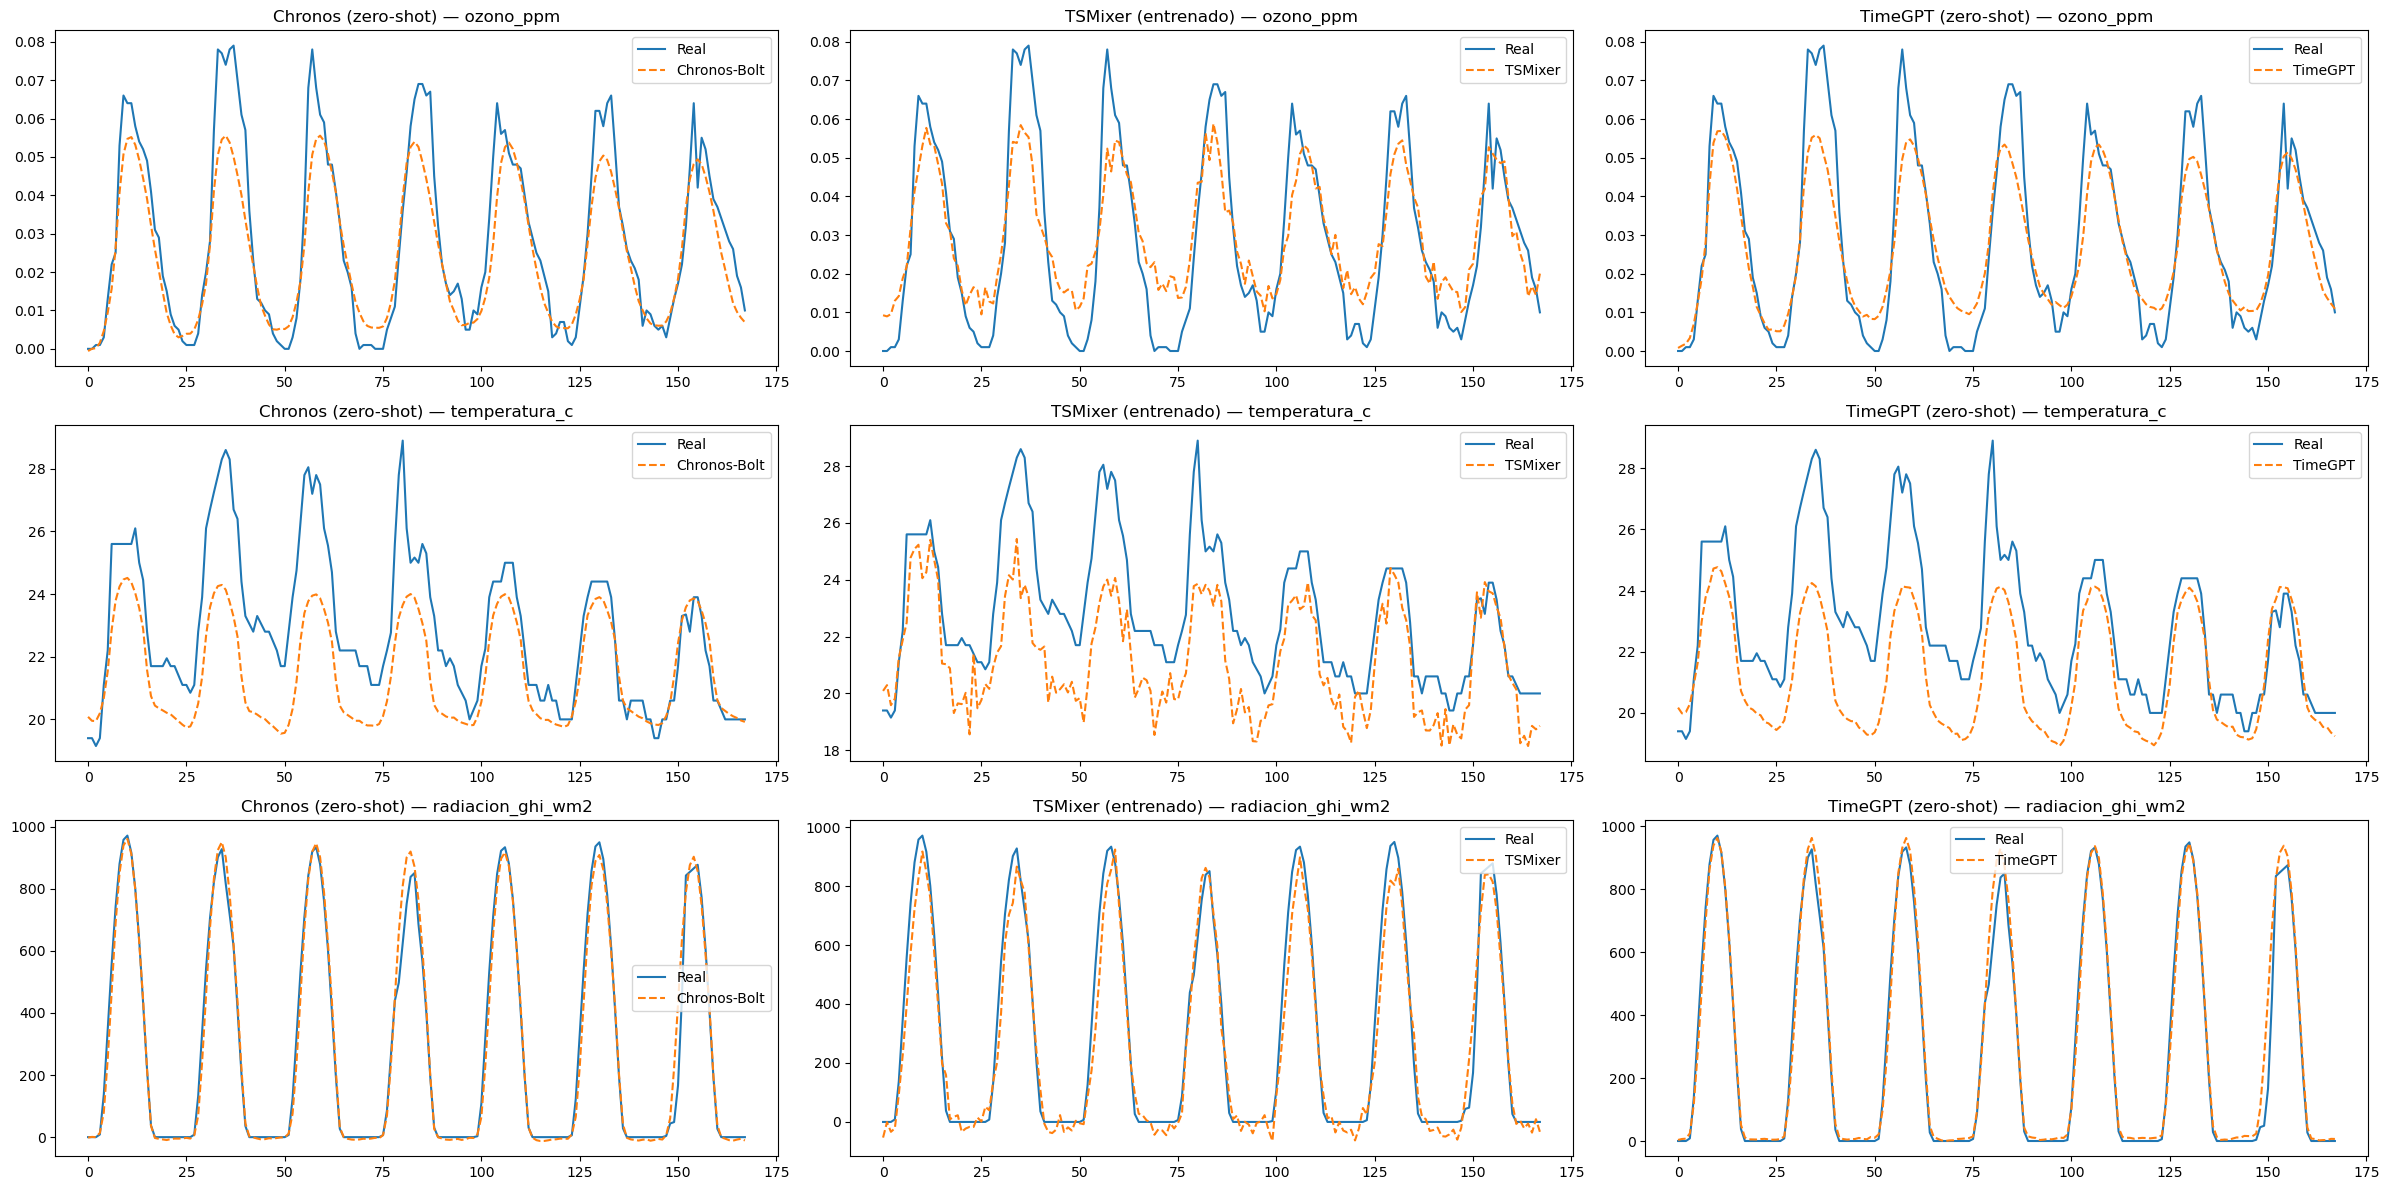

In [15]:
tiene_timegpt = len(resultados_timegpt) > 0
n_columnas = 3 if tiene_timegpt else 2
fig, axes = plt.subplots(len(datos.columns), n_columnas, figsize=(8 * n_columnas, 12))

for fila, col in enumerate(datos.columns):
    axes[fila, 0].plot(resultados_chronos[col]["_test_real"], label="Real")
    axes[fila, 0].plot(resultados_chronos[col]["_test_pred"], label="Chronos-Bolt", linestyle="--")
    axes[fila, 0].set_title(f"Chronos (zero-shot) — {col}")
    axes[fila, 0].legend()

    axes[fila, 1].plot(resultados_tsmixer[col]["_test_real"], label="Real")
    axes[fila, 1].plot(resultados_tsmixer[col]["_test_pred"], label="TSMixer", linestyle="--")
    axes[fila, 1].set_title(f"TSMixer (entrenado) — {col}")
    axes[fila, 1].legend()

    if tiene_timegpt:
        axes[fila, 2].plot(resultados_timegpt[col]["_test_real"], label="Real")
        axes[fila, 2].plot(resultados_timegpt[col]["_test_pred"], label="TimeGPT", linestyle="--")
        axes[fila, 2].set_title(f"TimeGPT (zero-shot) — {col}")
        axes[fila, 2].legend()

plt.tight_layout()
plt.show()

## 6. Guardado de resultados

In [16]:
def limpiar(resultados):
    return {col: {k: v for k, v in r.items() if not k.startswith("_")} for col, r in resultados.items()}

(PROJECT_ROOT / "data/processed/resultados_chronos.json").write_text(
    json.dumps(limpiar(resultados_chronos), indent=2), encoding="utf-8"
)
(PROJECT_ROOT / "data/processed/resultados_tsmixer.json").write_text(
    json.dumps(limpiar(resultados_tsmixer), indent=2), encoding="utf-8"
)
if resultados_timegpt:
    (PROJECT_ROOT / "data/processed/resultados_timegpt.json").write_text(
        json.dumps(limpiar(resultados_timegpt), indent=2), encoding="utf-8"
    )

print("Chronos:", json.dumps(limpiar(resultados_chronos), indent=2))
print("\nTSMixer:", json.dumps(limpiar(resultados_tsmixer), indent=2))
if resultados_timegpt:
    print("\nTimeGPT:", json.dumps(limpiar(resultados_timegpt), indent=2))
else:
    print("\nTimeGPT: sección saltada (sin API key todavía)")

print("\nNotebook 12 completo — pipeline del TP2 (08-12) terminado.")

Chronos: {
  "ozono_ppm": {
    "MAE": 0.006746907815603273,
    "RMSE": 0.009576287157960576
  },
  "temperatura_c": {
    "MAE": 1.4980142146822009,
    "RMSE": 1.9097678547617891
  },
  "radiacion_ghi_wm2": {
    "MAE": 25.97810191199893,
    "RMSE": 47.88636296596468
  }
}

TSMixer: {
  "ozono_ppm": {
    "MAE": 0.009125346883599247,
    "RMSE": 0.01119066797131464
  },
  "temperatura_c": {
    "MAE": 1.7333029572925873,
    "RMSE": 2.0874542217781333
  },
  "radiacion_ghi_wm2": {
    "MAE": 52.30324149016468,
    "RMSE": 72.35932973265632
  }
}

TimeGPT: {
  "ozono_ppm": {
    "MAE": 0.0068849993000000016,
    "RMSE": 0.009488933131297572
  },
  "temperatura_c": {
    "MAE": 1.7052534305555556,
    "RMSE": 2.055573160972159
  },
  "radiacion_ghi_wm2": {
    "MAE": 25.67530826672619,
    "RMSE": 47.67311495587296
  }
}

Notebook 12 completo — pipeline del TP2 (08-12) terminado.
